# PRIMER for PREM model

Now it runs with my hmgeolib environment, there may be version differnece in the obspy package and syntax.

## Utility functions

In [1]:
# -------------------------------
# Annotation helper (robust)
# -------------------------------
def annotate_at_depth(ax, depths, values, depth_points, fmt="{:.0f}", x_offset=0.02):
    depths = np.asarray(depths)
    values = np.asarray(values)

    xmin, xmax = ax.get_xlim()
    dx = (xmax - xmin) * x_offset

    for d in depth_points:
        idx = np.abs(depths - d).argmin()
        val = values[idx]

        ax.text(val + dx, depths[idx],
                fmt.format(val),
                fontsize=8,
                va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"))

# Use obspy for mantle profiles

Note obspy only has density, Vp and Vs. With this, we can derive the values of compressibility and bulk modulus. Therefore, 5 values can be plotted with the obspy example.

Here, we marks depth 400, 650 and 1000 km for comparison

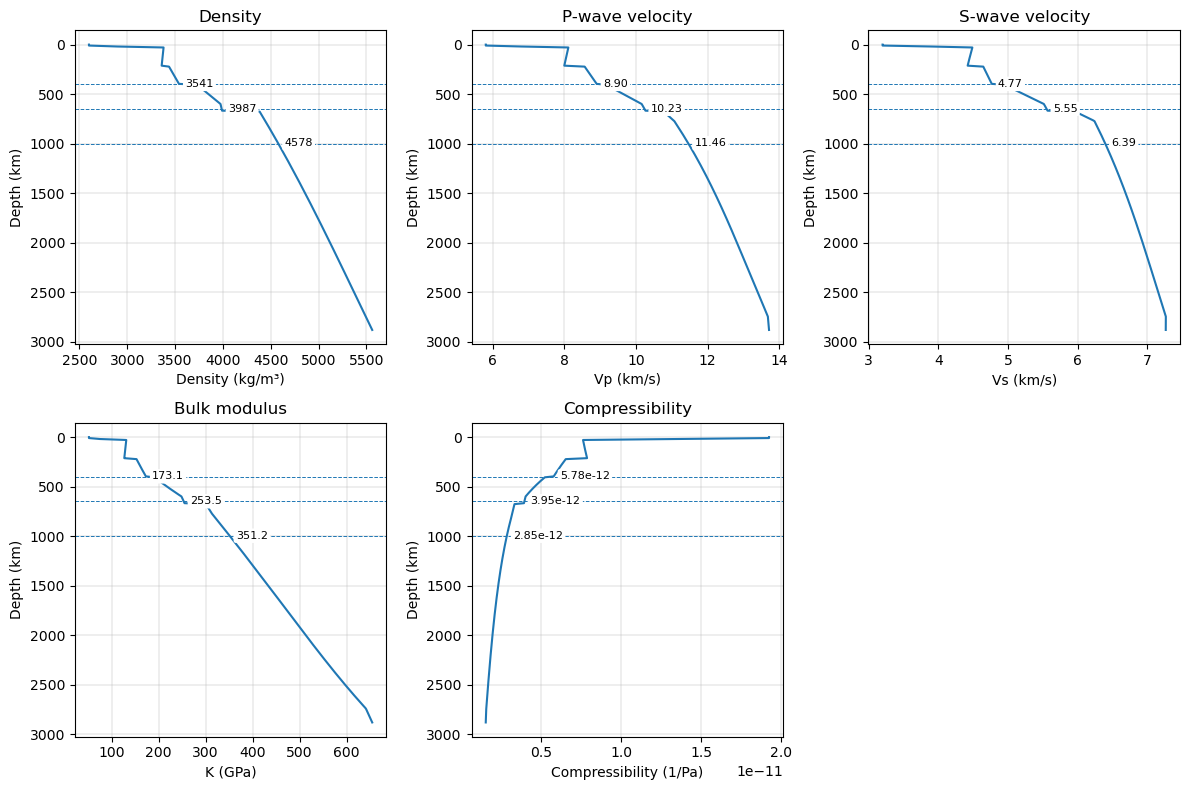

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from obspy.taup import TauPyModel

# -------------------------------
# Load PREM model
# -------------------------------
model = TauPyModel(model="prem")

depths = np.linspace(0, 2891, 300)

# Extract properties
rho = model.model.s_mod.v_mod.evaluate_below(depths, "d") * 1000  # kg/m^3
vp  = model.model.s_mod.v_mod.evaluate_below(depths, "p") * 1000  # m/s
vs  = model.model.s_mod.v_mod.evaluate_below(depths, "s") * 1000  # m/s

# -------------------------------
# Derived properties
# -------------------------------
K = rho * (vp**2 - (4.0/3.0) * vs**2)   # Pa
beta = 1.0 / K                          # 1/Pa

# -------------------------------
# Apply depth mask (0–2890 km)
# -------------------------------
mask = (depths >= 0) & (depths <= 2890)

depths = depths[mask]
rho = rho[mask]
vp = vp[mask]
vs = vs[mask]
K = K[mask]
beta = beta[mask]



# -------------------------------
# Figure layout
# -------------------------------
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 3, figure=fig)

ax_rho = fig.add_subplot(gs[0, 0])
ax_vp  = fig.add_subplot(gs[0, 1])
ax_vs  = fig.add_subplot(gs[0, 2])

ax_K    = fig.add_subplot(gs[1, 0])
ax_beta = fig.add_subplot(gs[1, 1])
ax_blank = fig.add_subplot(gs[1, 2])

axes = [ax_rho, ax_vp, ax_vs, ax_K, ax_beta]

# -------------------------------
# Common formatting
# -------------------------------
for ax in axes:
    ax.invert_yaxis()
    ax.set_ylabel("Depth (km)")
    ax.grid(True, linewidth=0.3)

# Horizontal lines (UPDATED)
depth_markers = [400, 650, 1000]
for ax in axes:
    for d in depth_markers:
        ax.axhline(d, linestyle="--", linewidth=0.7)

# -------------------------------
# Plotting
# -------------------------------
ax_rho.plot(rho, depths)
ax_rho.set_xlabel("Density (kg/m³)")
ax_rho.set_title("Density")

ax_vp.plot(vp / 1000, depths)
ax_vp.set_xlabel("Vp (km/s)")
ax_vp.set_title("P-wave velocity")

ax_vs.plot(vs / 1000, depths)
ax_vs.set_xlabel("Vs (km/s)")
ax_vs.set_title("S-wave velocity")

ax_K.plot(K / 1e9, depths)
ax_K.set_xlabel("K (GPa)")
ax_K.set_title("Bulk modulus")

ax_beta.plot(beta, depths)
ax_beta.set_xlabel("Compressibility (1/Pa)")
ax_beta.set_title("Compressibility")

# -------------------------------
# Add annotations (UPDATED)
# -------------------------------
annotate_at_depth(ax_rho, depths, rho, depth_markers, fmt="{:.0f}")
annotate_at_depth(ax_vp, depths, vp/1000, depth_markers, fmt="{:.2f}")
annotate_at_depth(ax_vs, depths, vs/1000, depth_markers, fmt="{:.2f}")
annotate_at_depth(ax_K, depths, K/1e9, depth_markers, fmt="{:.1f}")
annotate_at_depth(ax_beta, depths, beta, depth_markers, fmt="{:.2e}")

# Hide unused panel
ax_blank.axis("off")

# -------------------------------
# Final layout
# -------------------------------
plt.tight_layout()
plt.show()

# Use Burnman for mantle profiles

In burn, compositions are composite from mineral assemblage, therefore we can make pyrolite from olivine, pyroxene, etc.

## First, do a quick check with olivine

At different depth ranges, we need to select different minear type (olivine, wadsleyite, ringwoodite, etc.)

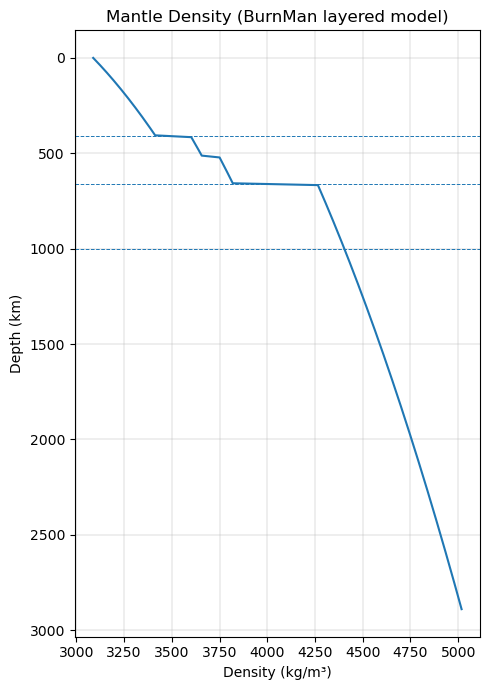

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import burnman

# -------------------------------
# Define minerals (SLB 2011)
# -------------------------------
from burnman.minerals import SLB_2011

olivine = SLB_2011.forsterite()
wadsleyite = SLB_2011.mg_wadsleyite()
ringwoodite = SLB_2011.mg_ringwoodite()
bridgmanite = SLB_2011.mg_perovskite()

# -------------------------------
# Depth grid (km)
# -------------------------------
depths = np.linspace(0, 2890, 300)

# -------------------------------
# Simple P-T profiles
# -------------------------------
g = 9.8
rho_ref = 3300

P = rho_ref * g * depths * 1000
T = 1600 + 0.35 * depths

# -------------------------------
# Compute density (layered mantle)
# -------------------------------
rho = []

for d, p, t in zip(depths, P, T):

    if d < 410:
        mineral = olivine
    elif d < 520:
        mineral = wadsleyite
    elif d < 660:
        mineral = ringwoodite
    else:
        mineral = bridgmanite

    mineral.set_state(p, t)
    rho.append(mineral.density)   # <-- FIX HERE

rho = np.array(rho)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(5, 7))

plt.plot(rho, depths)
plt.gca().invert_yaxis()

plt.xlabel("Density (kg/m³)")
plt.ylabel("Depth (km)")
plt.title("Mantle Density (BurnMan layered model)")

for d in [410, 660, 1000]:
    plt.axhline(d, linestyle="--", linewidth=0.7)

plt.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()

## Second, composite the pyrolite composition

Here, we also mark depth 400, 650 and 1000 km for comparison

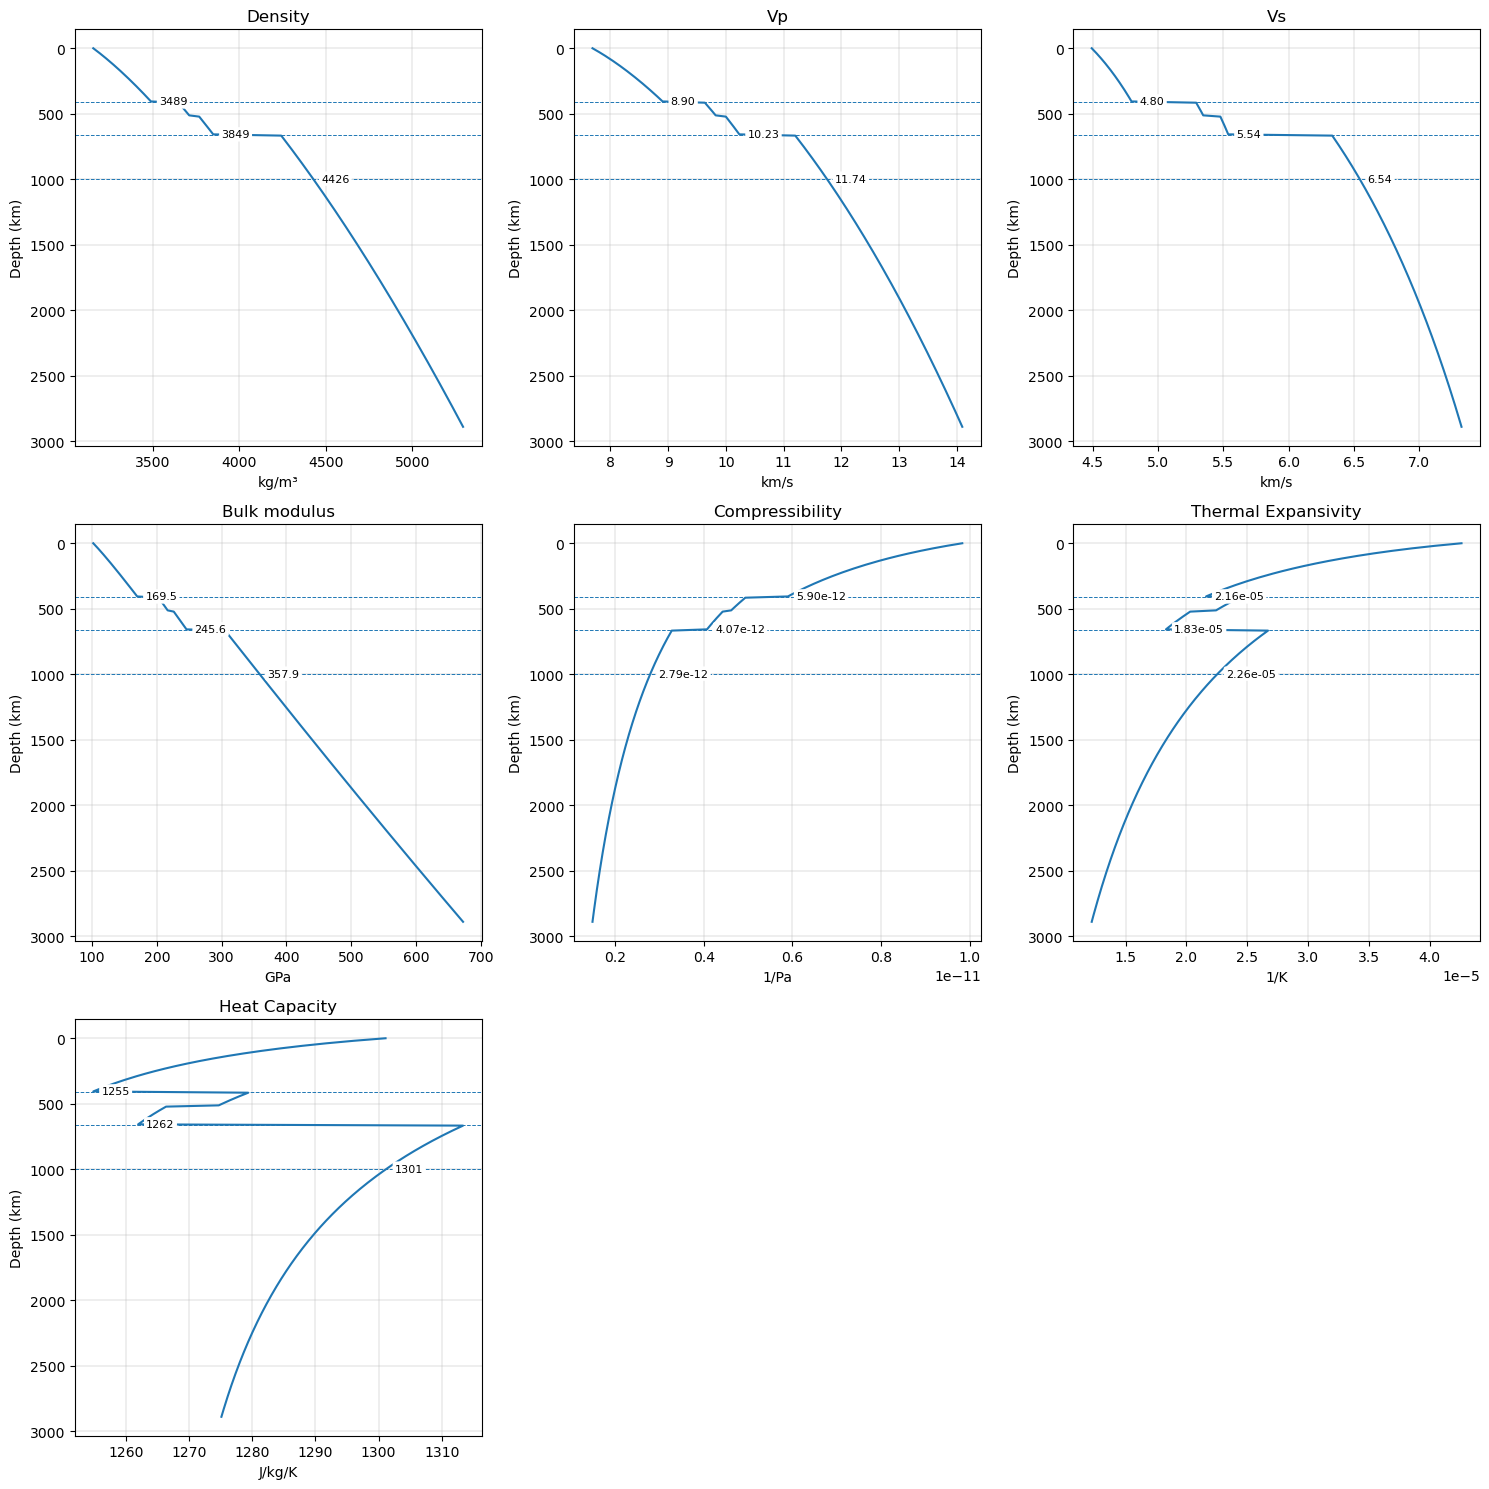

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import burnman

# -------------------------------
# Define minerals
# -------------------------------
from burnman.minerals import SLB_2011

ol = SLB_2011.forsterite()
opx = SLB_2011.enstatite()
cpx = SLB_2011.diopside()
gt = SLB_2011.pyrope()

wad = SLB_2011.mg_wadsleyite()
ring = SLB_2011.mg_ringwoodite()

pv = SLB_2011.mg_perovskite()
fp = SLB_2011.periclase()

# -------------------------------
# Build composites
# -------------------------------
pyrolite_upper = burnman.Composite([ol, opx, cpx, gt], [0.60, 0.20, 0.10, 0.10])
pyrolite_tz_wad = burnman.Composite([wad, gt], [0.80, 0.20])
pyrolite_tz_ring = burnman.Composite([ring, gt], [0.80, 0.20])
pyrolite_lower = burnman.Composite([pv, fp], [0.80, 0.20])

# -------------------------------
# Depth grid
# -------------------------------
depths = np.linspace(0, 2890, 300)
dz = np.gradient(depths) * 1000

# -------------------------------
# Temperature profile
# -------------------------------
T = 1600 + 0.35 * depths

# -------------------------------
# Initialize arrays
# -------------------------------
g = 9.8

P = np.zeros_like(depths)
rho = np.ones_like(depths) * 3300

vp = np.zeros_like(depths)
vs = np.zeros_like(depths)
K = np.zeros_like(depths)

alpha = np.zeros_like(depths)
Cp = np.zeros_like(depths)

# -------------------------------
# Iterative solve
# -------------------------------
for iteration in range(5):

    for i, (d, p, t) in enumerate(zip(depths, P, T)):

        if d < 410:
            material = pyrolite_upper
        elif d < 520:
            material = pyrolite_tz_wad
        elif d < 660:
            material = pyrolite_tz_ring
        else:
            material = pyrolite_lower

        material.set_state(p, t)

        rho[i] = material.density
        vp[i]  = material.v_p
        vs[i]  = material.v_s
        K[i]   = material.K_S

        alpha[i] = material.thermal_expansivity
        Cp[i] = material.C_p / material.molar_mass   # J/kg/K

    # update pressure
    P[0] = 0.0
    for i in range(1, len(depths)):
        P[i] = P[i-1] + rho[i-1] * g * dz[i-1]

# -------------------------------
# Derived
# -------------------------------
beta = 1.0 / K
# -------------------------------
# Plot (3x3 layout, 3 columns)
# -------------------------------
fig = plt.figure(figsize=(15, 15))
gs = GridSpec(3, 3, figure=fig)

ax_rho   = fig.add_subplot(gs[0, 0])
ax_vp    = fig.add_subplot(gs[0, 1])
ax_vs    = fig.add_subplot(gs[0, 2])

ax_K     = fig.add_subplot(gs[1, 0])
ax_beta  = fig.add_subplot(gs[1, 1])
ax_alpha = fig.add_subplot(gs[1, 2])

ax_Cp    = fig.add_subplot(gs[2, 0])
ax_blank1 = fig.add_subplot(gs[2, 1])
ax_blank2 = fig.add_subplot(gs[2, 2])

axes = [ax_rho, ax_vp, ax_vs, ax_K, ax_beta, ax_alpha, ax_Cp]

# -------------------------------
# Common formatting
# -------------------------------
for ax in axes:
    ax.invert_yaxis()
    ax.set_ylabel("Depth (km)")
    ax.grid(True, linewidth=0.3)

depth_markers = [410, 660, 1000]
for ax in axes:
    for d in depth_markers:
        ax.axhline(d, linestyle="--", linewidth=0.7)

# -------------------------------
# Plotting
# -------------------------------
ax_rho.plot(rho, depths)
ax_rho.set_title("Density")
ax_rho.set_xlabel("kg/m³")

ax_vp.plot(vp / 1000, depths)
ax_vp.set_title("Vp")
ax_vp.set_xlabel("km/s")

ax_vs.plot(vs / 1000, depths)
ax_vs.set_title("Vs")
ax_vs.set_xlabel("km/s")

ax_K.plot(K / 1e9, depths)
ax_K.set_title("Bulk modulus")
ax_K.set_xlabel("GPa")

ax_beta.plot(beta, depths)
ax_beta.set_title("Compressibility")
ax_beta.set_xlabel("1/Pa")

ax_alpha.plot(alpha, depths)
ax_alpha.set_title("Thermal Expansivity")
ax_alpha.set_xlabel("1/K")

ax_Cp.plot(Cp, depths)
ax_Cp.set_title("Heat Capacity")
ax_Cp.set_xlabel("J/kg/K")

# Hide unused panels
ax_blank1.axis("off")
ax_blank2.axis("off")

# -------------------------------
# Annotation (your utility)
# -------------------------------
annotate_at_depth(ax_rho, depths, rho, depth_markers, "{:.0f}")
annotate_at_depth(ax_vp, depths, vp/1000, depth_markers, "{:.2f}")
annotate_at_depth(ax_vs, depths, vs/1000, depth_markers, "{:.2f}")
annotate_at_depth(ax_K, depths, K/1e9, depth_markers, "{:.1f}")
annotate_at_depth(ax_beta, depths, beta, depth_markers, "{:.2e}")
annotate_at_depth(ax_alpha, depths, alpha, depth_markers, "{:.2e}")
annotate_at_depth(ax_Cp, depths, Cp, depth_markers, "{:.0f}")

# -------------------------------
# Final layout
# -------------------------------
plt.tight_layout()
plt.show()